# Calcul de similarité sémantique avec SBERT

1. Chargement du corpus parallèle à partir des fichier `.txt`
2. Création des sous-ensembles semi-parallèle et parallèle
3. Calcule du score de similarité sémantique avec `paraphrase-multilingual-MiniLM-L12-v2`
4. Calcul des caractéristiques complémentaire (score de longueur, score Jaccard et similarité phonétique)
5. Exporter le dataset annoté sous forme de `.csv`

---

### Format prévu

Chaque fichier contiens **une phrase par ligne**.
Le texte source en français et la cible en langue régionale doit posséder **le même nombre de ligne non-vide**.

2 architectures de dossier sont acceptées

#### Architecture 1 — source en français partagée (Atlas LIMSI / Fils prodigue)
Un seul fichier en français et le fichier source qui sera aparié aux fichiers dans les divers langues régionales

```
corpus/
├── fr.txt                
├── gsw_strasbourg.txt
├── gsw_mulhouse.txt      
├── co_ajaccio.txt        
├── oc_beyssac.txt
└── oc_gascon.txt         
```

#### Architecture B — Source en français séparée (ParCoLab)
Chaque fichier dans le dossier parent à un dossier source en français et des traductions dans les langues régionales.

```
corpus/
├── bisesoleil_or_fr.txt
├── bisesoleil_or_gsw.txt
└── ...
```



---


## Installation et imports

In [1]:
!pip install sentence-transformers jellyfish pandas numpy scikit-learn tqdm matplotlib

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.13/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import os
import random
import unicodedata
import re
import string

import pandas as pd
import numpy as np
import jellyfish
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# Reproducibility
random.seed(42)
np.random.seed(42)

/home/t.dumortier/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm




---


## Configuration

Chaque entrées dans `FILE_PAIRS` contient:
- Un **fichier source en français**
- Un **fichier dans la langue régionale cible**
- Un **label** identifiant la paire de langues

In [3]:
# Directory containing the .txt files
CORPUS_DIR = "../data/"
CORPUS_DIRECTORIES = [
    "../data/paralleles/limsi_aligned/",
    "../data/paralleles/parable_filsprod/",
    "../data/paralleles/parcolab/"
]

# List of aligned file pairs: (french_source_file, regional_target_file, label)
FILE_PAIRS = []
# Adding all texts from the LIMSI atlas
for i, corpus in enumerate(CORPUS_DIRECTORIES) :
  if i == 0 :
    for file in os.listdir(corpus):
      if file != "Fable_esope_la_bise_et_le_soleil_fr_paris.txt":
        lang = "fr-"+file.split('_')[7]
        corpus = "LIMSI"
        FILE_PAIRS.append(("Fable_esope_la_bise_et_le_soleil_fr_paris.txt",  file, lang, 0, corpus))
  elif i == 1 :
    for file in os.listdir(corpus):
      if file != "filsprod_fr.txt":
        lang = "fr-"+file.split('_')[1]
        corpus = "fils prodigue"
        FILE_PAIRS.append(("filsprod_fr.txt", file, lang, 1, corpus))
  else :
    spec_pairs = {}
    viewed_files = []
    for file in os.listdir(corpus):
        viewed_files.append(file)
    for file in viewed_files:
      if "_fr" in file:
        print(file)
        [print(f) for f in viewed_files if file[0:-7] in f]
        spec_pairs[file] = [f for f in viewed_files if file[0:-7] in f]
    for p in spec_pairs:
      for f in spec_pairs[p]:
        if p == f:
          continue
        if f.split('_')[2] != "gsw.txt":
          lang = "fr-"+f.split('_')[2][:-4]
        else :
          lang = "fr-gsw"
        corpus = "Parcolab"
        FILE_PAIRS.append((p, f, lang, 2, corpus))

[print(f"{f[0]} + {f[1]} + {f[2]}") for f in FILE_PAIRS]

# SBERT model
SBERT_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"

# Number of pairs per subset category
# None = use all available parallel pairs
# Integer = sample exactly that many pairs per category
SUBSET_SIZE = None

# Output file
OUTPUT_FILE = "similarity_dataset.csv"

print(f"Configuration loaded: {len(FILE_PAIRS)} file pairs defined.")

filsprodigue_tr_fr.txt
filsprodigue_tr_fr.txt
filsprodigue_tr_gsw.txt
filsprodigue_tr_co.txt
filsprodigue_tr_oc.txt
bisesoleil_or_fr.txt
bisesoleil_or_fr.txt
bisesoleil_or_gsw.txt
feltin-20211123_tr_fr.txt
feltin-20211123_tr_fr.txt
feltin-20211123_tr_gsw.txt
feltin-20211123_tr_oc.txt
feltin-20211123_tr_co.txt
feltin-20230207_tr_fr.txt
feltin-20230207_tr_co.txt
feltin-20230207_tr_fr.txt
feltin-20230207_tr_gsw.txt
feltin-20230207_tr_oc.txt
boccace_tr_fr.txt
boccace_tr_oc.txt
boccace_tr_fr.txt
boccace_tr_co.txt
boccace_tr_gsw.txt
pierreloup_or_fr.txt
pierreloup_or_fr.txt
feltin-20220308_tr_fr.txt
feltin-20220308_tr_co.txt
feltin-20220308_tr_oc.txt
feltin-20220308_tr_gsw.txt
feltin-20220308_tr_fr.txt
feltin-20210921_tr_fr.txt
feltin-20210921_tr_gsw.txt
feltin-20210921_tr_co.txt
feltin-20210921_tr_oc.txt
feltin-20210921_tr_fr.txt
universal_tr_fr.txt
universal_tr_gsw.txt
universal_tr_oc.txt
universal_tr_co.txt
universal_tr_fr.txt
Fable_esope_la_bise_et_le_soleil_fr_paris.txt + Fable_esope_la



---


## Chargement des corpus parallèles

In [4]:
def read_sentences(filepath):
    """
    Read a .txt file and return a list of non-empty stripped sentences.
    Compatible with files that have or do not have a trailing newline.
    """
    with open(filepath, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]


def load_pair(fr_path, lr_path, label):
    """
    Load two aligned .txt files.
    Returns a list of tuples (fr_sentence, lr_sentence, label).
    If sentence counts differ, prints a warning and doesn't load pair.
    """
    fr_sentences = read_sentences(fr_path)
    lr_sentences = read_sentences(lr_path)

    if len(fr_sentences) != len(lr_sentences):
        n = min(len(fr_sentences), len(lr_sentences))
        print(f"[{lr_file}] Misalignment: {len(fr_sentences)} FR / "
              f"{len(lr_sentences)} LR → Not loaded")
        fr_sentences, lr_sentences = [], []

    return [(fr, lr, label) for fr, lr in zip(fr_sentences, lr_sentences)]


print("Loading parallel corpora...\n")
parallel_pairs = []

for fr_file, lr_file, label, dir_id, _corpus in FILE_PAIRS:
    fr_path = os.path.join(CORPUS_DIRECTORIES[dir_id], fr_file)
    lr_path = os.path.join(CORPUS_DIRECTORIES[dir_id], lr_file)

    if not os.path.exists(fr_path):
        print(f"- [{fr_file}] File not found: {fr_path}")
        continue
    if not os.path.exists(lr_path):
        print(f"- [{lr_file}] File not found: {lr_path}")
        continue

    pairs = load_pair(fr_path, lr_path, label)
    parallel_pairs.extend(pairs)
    print(f"+ [{lr_file}] {len(pairs)} pairs loaded")

print(f"\nTotal parallel pairs loaded: {len(parallel_pairs)}")

# Warn if the corpus is very small
if len(parallel_pairs) < 50:
    print(f"\n Small corpus ({len(parallel_pairs)} pairs). "
          f"Consider adding more dialect files to FILE_PAIRS for robust training.")

Loading parallel corpora...

+ [Fable_esope_la_bise_et_le_soleil_oc_lan_codebronde.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_co_corte.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_noc_montrollet.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_lan_lepontdemontvert_mi.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_co_monacia_daullene.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_noc_arsac.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_noc_roiffieux.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_noc_besse.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_gsw_rixheim.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_lan_toulouse.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_lan_puygouzon.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_noc_mussidan.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_noc_mirabel.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_sol

In [5]:
def inspect_corpus(pairs, n_per_label=2):
    """
    Display a sample of loaded pairs grouped by language label.
    Useful for visually verifying alignment quality.
    """
    from collections import defaultdict
    by_label = defaultdict(list)
    for fr, lr, lbl in pairs:
        by_label[lbl].append((fr, lr))

    for label, examples in by_label.items():
        print(f"\n{'='*70}")
        print(f" {label}  ({len(examples)} pairs total)")
        print('='*70)
        for fr, lr in examples[:n_per_label]:
            print(f"  FR: {fr[:100]}")
            print(f"  LR: {lr[:100]}")
            print()

inspect_corpus(parallel_pairs)


 fr-oc  (485 pairs total)
  FR: La bise et le soleil se disputaient, chacun assurant qu'il était le plus fort, quand ils ont vu un v
  LR: Le cèrç e le solelh se carpinhavan, cadun assegurant qu'èra le mai fòrt, quand vegèron un viatjaire 

  FR: Ils sont tombés d'accord que celui qui arriverait le premier à faire ôter son manteau au voyageur se
  LR: Se metèron d'acòrdi qu'aquel que capitariá le primièr a faire levar son mantèl al viatjaire seriá di


 fr-co  (391 pairs total)
  FR: La bise et le soleil se disputaient, chacun assurant qu'il était le plus fort, quand ils ont vu un v
  LR: A tramuntana è u sole si litigavanu, ognunu assicurendu ch'ellu era u più forte, quand'elli anu vist

  FR: Ils sont tombés d'accord que celui qui arriverait le premier à faire ôter son manteau au voyageur se
  LR: Si sò intesi chì quellu chì riescirà u primu à fà caccià u so mantellu à u viaghjatore serà vistu cu


 fr-gsw  (269 pairs total)
  FR: La bise et le soleil se disputaient, chacun assurant



---


## Création des sous-ensembles

Trois sous-ensembles sont créés à partir des données parallèles

| sous-ensembles | Construction |
|---|---|
| **Parallèles** | Les paires venant des fichiers |
| **Semi-parallèles** | Paires parallèles où la phrase dans la langue cible est tronquée |
| **Non parallèles** | Paires apariant 2 phrases aléatoires |

In [6]:
def build_parallel_subset(pairs, size=None):
    """
    Build the parallel subset.
    If size is set, randomly samples that many pairs from the full list.
    """
    if size and size < len(pairs):
        pairs = random.sample(pairs, size)
    return [(fr, lr, lbl, "parallel") for fr, lr, lbl in pairs]


def build_semi_parallel_subset(pairs, size):
    """
    Build the semi-parallel subset by truncating the target sentence.

    Strategy 1 (preferred): split after the first comma, semicolon or colon
                            and keep the first segment.
    Strategy 2 (fallback):  keep only the first half of words when no
                            internal punctuation is available.
    """
    sample = random.sample(pairs, min(size, len(pairs)))
    subset = []

    for fr, lr, lbl in sample:
        segments = re.split(r'[,;:]', lr, maxsplit=1)
        if len(segments) > 1 and len(segments[0].strip()) > 3:
            truncated = segments[0].strip()
        else:
            words = lr.split()
            truncated = " ".join(words[:max(1, len(words) // 2)])
        subset.append((fr, truncated, lbl, "semi-parallel"))

    return subset


def build_non_parallel_subset(pairs, size):
    """
    Build the non-parallel subset by randomly pairing FR and LR sentences
    at different positions.

    Checks that the generated pair does not already exist in the parallel
    set to avoid introducing false negatives.
    """
    fr_sentences   = [p[0] for p in pairs]
    lr_sentences   = [p[1] for p in pairs]
    labels         = [p[2] for p in pairs]
    existing_pairs = set((p[0], p[1]) for p in pairs)

    subset   = []
    attempts = 0

    while len(subset) < size and attempts < size * 20:
        i = random.randint(0, len(fr_sentences) - 1)
        j = random.randint(0, len(lr_sentences) - 1)
        attempts += 1
        if i != j and (fr_sentences[i], lr_sentences[j]) not in existing_pairs:
            subset.append((fr_sentences[i], lr_sentences[j], labels[i], "non-parallel"))
            existing_pairs.add((fr_sentences[i], lr_sentences[j]))

    if len(subset) < size:
        print(f"Only {len(subset)}/{size} non-parallel pairs generated. ")
    return subset


# -------------------------------------------------------
# Build the three subsets
# -------------------------------------------------------
target_size = min(SUBSET_SIZE or len(parallel_pairs), len(parallel_pairs))
print(f"Target size per subset: {target_size}\n")

subset_parallel      = build_parallel_subset(parallel_pairs, target_size)
print(f"- Parallel subset:      {len(subset_parallel)} pairs")

subset_semi          = build_semi_parallel_subset(parallel_pairs, target_size)
print(f"- Semi-parallel subset: {len(subset_semi)} pairs")

subset_non_parallel  = build_non_parallel_subset(parallel_pairs, target_size)
print(f"- Non-parallel subset:  {len(subset_non_parallel)} pairs")

# Merge and shuffle the full dataset
dataset = subset_parallel + subset_semi + subset_non_parallel
random.shuffle(dataset)
print(f"\nFull shuffled dataset: {len(dataset)} pairs")

df = pd.DataFrame(dataset, columns=['français', 'régional', 'label', 'parallélisme'])
df.to_csv("shuffled_pairs.csv", index=False)

Target size per subset: 1145

- Parallel subset:      1145 pairs
- Semi-parallel subset: 1145 pairs
- Non-parallel subset:  1145 pairs

Full shuffled dataset: 3435 pairs




---


## Calcule des caractéristiques complémentaires

In [7]:
def normalize(text):
    """
    Normalize a string: lowercase, remove accents and punctuation.
    Applied before all Jaccard index computations to reduce orthographic
    noise, which is especially important for unstandardized regional languages.
    """
    text = text.lower()
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    return text.translate(str.maketrans("", "", string.punctuation)).strip()


def length_score(s1, s2):
    """
    Compute normalized length asymmetry between two sentences.
    score = |len(s1) - len(s2)| / max(len(s1), len(s2))
    0 = identical word count (favorable to parallelism)
    1 = very asymmetric (unfavorable)
    """
    n1, n2  = len(s1.split()), len(s2.split())
    max_len = max(n1, n2)
    return 0.0 if max_len == 0 else abs(n1 - n2) / max_len


def char_ngrams(text, n):
    """Return the set of character n-grams for a normalized string."""
    t = normalize(text)
    return set(t[i:i+n] for i in range(len(t) - n + 1))


def jaccard_index(set_a, set_b):
    """Compute the Jaccard index: |A∩B| / |A∪B|."""
    if not set_a and not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)


def jaccard_ngrams(s1, s2, n):
    """
    Compute the Jaccard index on character n-grams of two sentences.
    """
    return jaccard_index(char_ngrams(s1, n), char_ngrams(s2, n))


def metaphone_codes(text):
    """
    Encode each word using the Metaphone algorithm (jellyfish library).
    """
    codes = set()
    for word in normalize(text).split():
        try:
            code = jellyfish.metaphone(word)
            if code:
                codes.add(code)
        except Exception:
            pass
    return codes


def phonetic_jaccard(s1, s2):
    """Compute the Jaccard index on Metaphone phonetic representations."""
    return jaccard_index(metaphone_codes(s1), metaphone_codes(s2))

# -------------------------------------------------------
# Sanity check on the actual loaded data
# -------------------------------------------------------
if parallel_pairs:
    print("\n--- Sanity check on first loaded pair ---")
    fr_ex, lr_ex, lbl_ex = parallel_pairs[0]
    print(f"Label : {lbl_ex}")
    print(f"FR    : {fr_ex[:90]}")
    print(f"LR    : {lr_ex[:90]}")
    print(f"  Length score   : {length_score(fr_ex, lr_ex):.4f}")
    print(f"  Jaccard-2      : {jaccard_ngrams(fr_ex, lr_ex, 2):.4f}")
    print(f"  Jaccard-3      : {jaccard_ngrams(fr_ex, lr_ex, 3):.4f}")
    print(f"  Jaccard-4      : {jaccard_ngrams(fr_ex, lr_ex, 4):.4f}")
    print(f"  Phonetic       : {phonetic_jaccard(fr_ex, lr_ex):.4f}")


--- Sanity check on first loaded pair ---
Label : fr-oc
FR    : La bise et le soleil se disputaient, chacun assurant qu'il était le plus fort, quand ils o
LR    : Le cèrç e le solelh se carpinhavan, cadun assegurant qu'èra le mai fòrt, quand vegèron un 
  Length score   : 0.1154
  Jaccard-2      : 0.4661
  Jaccard-3      : 0.2371
  Jaccard-4      : 0.1718
  Phonetic       : 0.2162




---


## Calcule du score SBERT

In [8]:
print(f"Loading SBERT model: {SBERT_MODEL} ...")
model = SentenceTransformer(SBERT_MODEL)

Loading SBERT model: paraphrase-multilingual-MiniLM-L12-v2 ...



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12741.83it/s]

In [9]:
def compute_sbert_scores(sentences_1, sentences_2, model, batch_size=64):
    """
    Compute SBERT cosine similarity scores for a list of sentence pairs.
    Processes in batches for memory efficiency.
    Scores are clipped to [0, 1] since cosine similarity can be slightly negative.
    Returns a list of float scores.
    """
    scores = []
    for i in tqdm(range(0, len(sentences_1), batch_size), desc="SBERT"):
        batch_1 = sentences_1[i:i+batch_size]
        batch_2 = sentences_2[i:i+batch_size]
        emb_1   = model.encode(batch_1, convert_to_numpy=True, show_progress_bar=False)
        emb_2   = model.encode(batch_2, convert_to_numpy=True, show_progress_bar=False)
        for v1, v2 in zip(emb_1, emb_2):
            scores.append(float(max(0.0, cosine_similarity([v1], [v2])[0][0])))
    return scores


all_fr_sentences = [pair[0] for pair in dataset]
all_lr_sentences = [pair[1] for pair in dataset]

print(f"Computing SBERT scores on {len(dataset)} pairs...")
sbert_scores = compute_sbert_scores(all_fr_sentences, all_lr_sentences, model)

Computing SBERT scores on 3435 pairs...



SBERT:   0%|          | 0/54 [00:00<?, ?it/s]


SBERT:   2%|▏         | 1/54 [00:02<01:48,  2.05s/it]


SBERT:   4%|▎         | 2/54 [00:04<01:54,  2.21s/it]


SBERT:   6%|▌         | 3/54 [00:08<02:26,  2.86s/it]

...


SBERT:  94%|█████████▍| 51/54 [02:58<00:09,  3.27s/it]


SBERT:  96%|█████████▋| 52/54 [03:01<00:06,  3.31s/it]


SBERT:  98%|█████████▊| 53/54 [03:05<00:03,  3.32s/it]


SBERT: 100%|██████████| 54/54 [03:08<00:00,  3.16s/it]


SBERT: 100%|██████████| 54/54 [03:08<00:00,  3.48s/it]



---


## Construction du dataframe annoté

In [10]:
print("Computing complementary features...")

rows = []
for idx, (fr, lr, lang_label, label_class) in enumerate(tqdm(dataset, desc="Features")):
    rows.append({
        "fr_sentence":         fr,
        "lr_sentence":         lr,
        "language_pair":       lang_label,
        "class":               label_class,
        # Binary label: 1 = parallel or semi-parallel | 0 = non-parallel
        "binary_class":        0 if label_class == "non-parallel" else 1,
        # SBERT cosine similarity score
        "sbert_score":         sbert_scores[idx],
        # Normalized length asymmetry
        "length_score":        length_score(fr, lr),
        # Character n-gram Jaccard indices
        "jaccard_bigrams":     jaccard_ngrams(fr, lr, 2),
        "jaccard_trigrams":    jaccard_ngrams(fr, lr, 3),
        "jaccard_quadrigrams": jaccard_ngrams(fr, lr, 4),
        # Phonetic Jaccard (Metaphone encoding)
        "phonetic_jaccard":    phonetic_jaccard(fr, lr),
    })

df = pd.DataFrame(rows)
df.head()

Computing complementary features...



Features:   0%|          | 0/3435 [00:00<?, ?it/s]


Features:   6%|▌         | 210/3435 [00:00<00:01, 1985.05it/s]


Features:  13%|█▎        | 436/3435 [00:00<00:01, 2140.07it/s]


Features:  22%|██▏       | 749/3435 [00:00<00:01, 2583.82it/s]

...


Features:  75%|███████▍  | 2563/3435 [00:00<00:00, 2943.90it/s]


Features:  85%|████████▍ | 2909/3435 [00:01<00:00, 3097.20it/s]


Features:  95%|█████████▌| 3271/3435 [00:01<00:00, 3235.52it/s]


Features: 100%|██████████| 3435/3435 [00:01<00:00, 2887.74it/s]

,fr_sentence,lr_sentence,language_pair,class,binary_class,sbert_score,length_score,jaccard_bigrams,jaccard_trigrams,jaccard_quadrigrams,phonetic_jaccard
0,Article 10,Articulu,fr-co,semi-parallel,1,0.827877,0.500000,0.333333,0.272727,0.200000,1.000000
1,"La bise et le soleil se disputaient, chacun as...",Lo sorelh e la bisa se capinhavan,fr-oc,semi-parallel,1,0.370990,0.730769,0.207921,0.061644,0.030864,0.111111
2,Ils sont tombés d'accord que celui qui arriver...,Se son acordats qu'aquèlo que capitariá lo pro...,fr-oc,parallel,1,0.372616,0.130435,0.446602,0.148571,0.069307,0.233333
3,"Devant la persécution, toute personne a le dro...",E jeder Mensch het s Racht,fr-gsw,semi-parallel,1,0.231251,0.684211,0.129870,0.018182,0.000000,0.000000
4,- Créer dans chaque région concernée des télév...,- Creà in ogni regione cuncernata televisioni ...,fr-co,parallel,1,0.915420,0.000000,0.542553,0.238994,0.149171,0.153846




---


## Analyse descriptive des sous-ensembles

In [11]:
numeric_features = [
    "sbert_score", "length_score",
    "jaccard_bigrams", "jaccard_trigrams",
    "jaccard_quadrigrams", "phonetic_jaccard"
]

print("=== Descriptive statistics by class ===")
print(df.groupby("class")[numeric_features].agg(["mean", "std"]).round(4).to_string())

print("\n=== Mean scores by language pair ===")
print(df.groupby("language_pair")[numeric_features].mean().round(4).to_string())

=== Descriptive statistics by class ===
              sbert_score         length_score         jaccard_bigrams         jaccard_trigrams         jaccard_quadrigrams         phonetic_jaccard        
                     mean     std         mean     std            mean     std             mean     std                mean     std             mean     std
class                                                                                                                                                       
non-parallel       0.2004  0.1601       0.5750  0.3258          0.1676  0.1343           0.0411  0.0576              0.0129  0.0449           0.0439  0.1062
parallel           0.6165  0.2725       0.0790  0.0896          0.4211  0.2447           0.1868  0.1848              0.1199  0.1751           0.2184  0.2618
semi-parallel      0.4594  0.2979       0.5617  0.2962          0.2499  0.2408           0.0911  0.1283              0.0584  0.1127           0.1495  0.2661

=== Mean scores b

In [12]:
# ── Color palette for classes ───────────────────────────────────────────────
CLASS_COLORS = {
    "non-parallel": "#e74c3c",  # red
    "semi-parallel": "#f39c12",  # orange
    "parallel": "#2ecc71",  # green
}


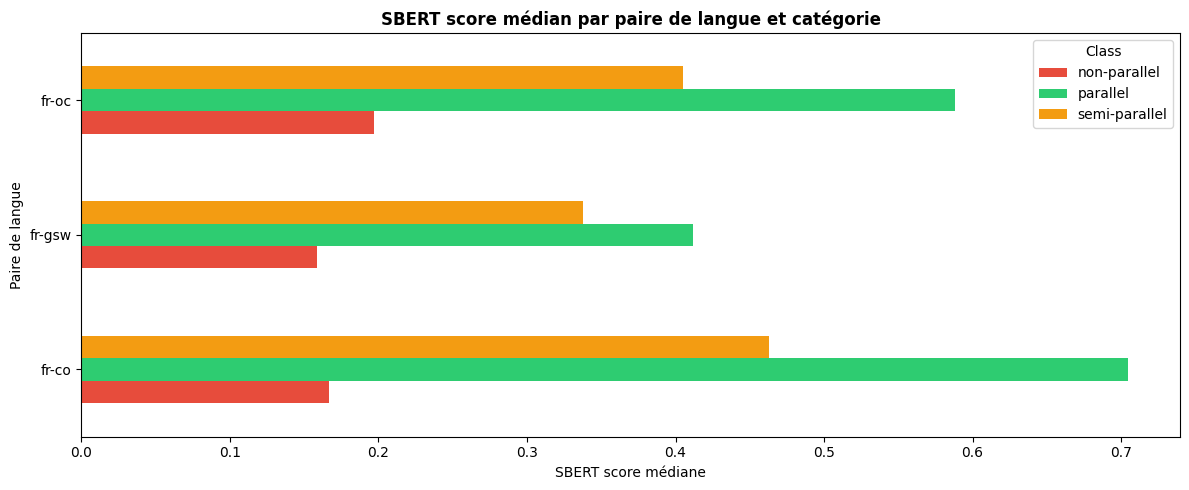

Figure saved: sbert_by_language_pair.png


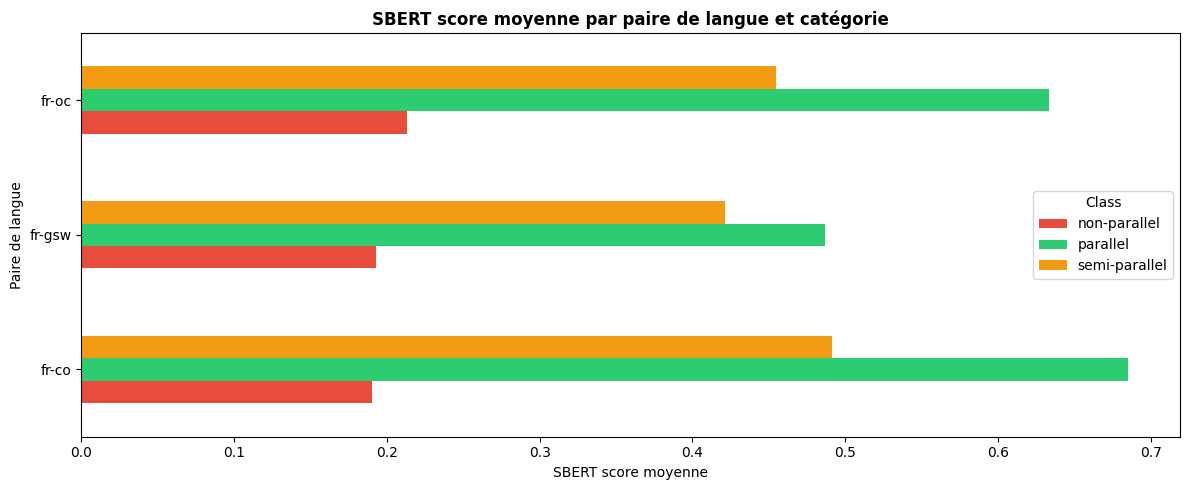

Figure saved: sbert_by_language_pair_mean.png

Vérification: SBERT score médian par langue et classe
language_pair  class        
fr-co          non-parallel     0.166882
               parallel         0.704433
               semi-parallel    0.463180
fr-gsw         non-parallel     0.158607
               parallel         0.411498
               semi-parallel    0.337640
fr-oc          non-parallel     0.196817
               parallel         0.588091
               semi-parallel    0.405214

Vérification: SBERT score moyenne par langue et classe
language_pair  class        
fr-co          non-parallel     0.190400
               parallel         0.684988
               semi-parallel    0.491333
fr-gsw         non-parallel     0.193073
               parallel         0.486746
               semi-parallel    0.421262
fr-oc          non-parallel     0.213476
               parallel         0.633303
               semi-parallel    0.454725


In [ ]:
# Common helper
def plot_sbert_bars(data: pd.DataFrame, group_col: str, statistic: str = "median", title: str = None, fname: str = None):
    """Plot SBERT scores grouped by language pair and class.
    statistic: 'mean' or 'median'
    """
    agg_fn = data["sbert_score"].median if statistic == "median" else data["sbert_score"].mean
    stat_label = "médiane" if statistic == "median" else "moyenne"
    if title is None:
        title = f"SBERT score {stat_label} par paire de langue et catégorie"
    if fname is None:
        fname = f"sbert_by_language_pair_{statistic}.png"

    pivot = data.groupby([group_col, "class"])["sbert_score"].agg(statistic).unstack()

    fig, ax = plt.subplots(figsize=(12, 5))
    pivot.plot(
        kind="barh", ax=ax,
        color=[CLASS_COLORS.get(c, "grey") for c in pivot.columns]
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(f"SBERT score {stat_label}")
    ax.set_ylabel("Paire de langue")
    ax.legend(title="Class")
    plt.tight_layout()
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure saved: {fname}")

# Graphs
plt.rcParams.update({'font.size': 10})

if len(df) >= 6:
    # Par paire de langue — médiane
    plot_sbert_bars(
        df, "language_pair", statistic="median",
        title="SBERT score médian par paire de langue et catégorie",
        fname="sbert_by_language_pair.png"
    )
    # Par paire de langue — moyenne
    plot_sbert_bars(
        df, "language_pair", statistic="mean",
        title="SBERT score moyen par paire de langue et catégorie",
        fname="sbert_by_language_pair_mean.png"
    )

# ── Vérification des valeurs par classe et langue ───────────────────────────
print("\n" + "=" * 60)
print("Vérification: SBERT score médian par langue et classe")
print("=" * 60)
median_table = df.groupby(["language_pair", "class"])["sbert_score"].median()
print(median_table.to_string())

print("\n" + "=" * 60)
print("Vérification: SBERT score moyenne par langue et classe")
print("=" * 60)
mean_table = df.groupby(["language_pair", "class"])["sbert_score"].mean()
print(mean_table.to_string())


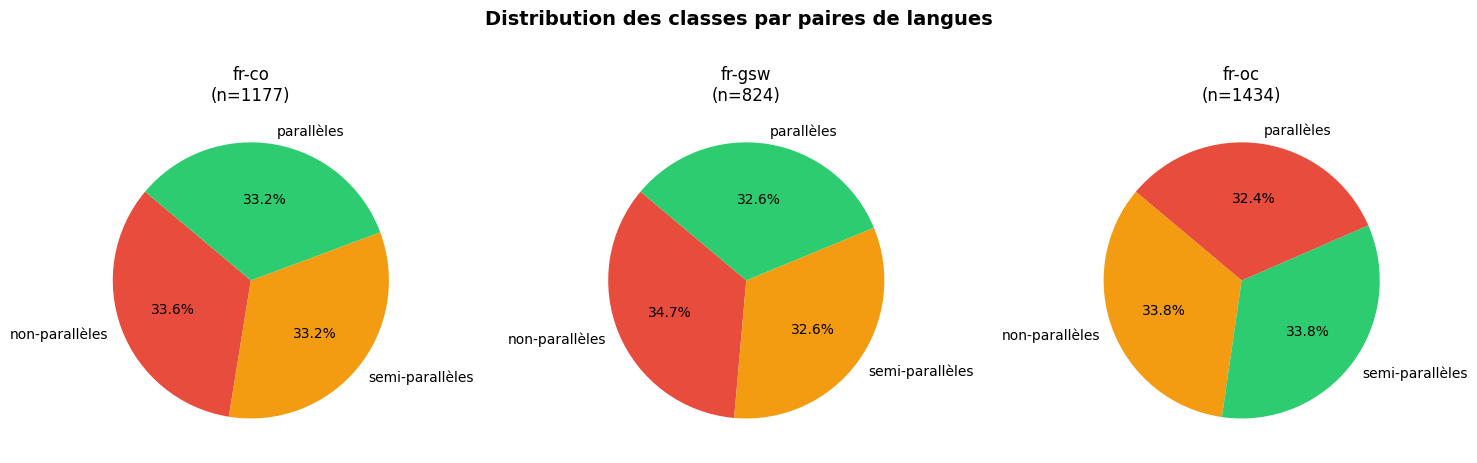

Figure saved: pie_by_language.png


In [14]:
# ── Helper pie chart ──────────────────────────────────────────────────────────
def plot_class_pie(data: pd.DataFrame, group_col: str | None, title: str, fname: str):
    """
    Creates a pie chart showing the distribution of classes in the dataset.
    """
    if group_col is None:
        counts = data["class"].value_counts()
        colors = [CLASS_COLORS.get(c, "grey") for c in counts.index]

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.pie(
            counts,
            labels=counts.index,
            colors=colors,
            autopct="%1.1f%%",
            startangle=140
        )
        ax.set_title(title)

    else:
        groups = sorted(data[group_col].unique())
        n = len(groups)
        ncols = min(n, 3)
        nrows = (n + ncols - 1) // ncols

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
        axes = np.array(axes).flatten()

        for i, grp in enumerate(groups):
            ax = axes[i]
            counts = data.loc[data[group_col] == grp, "class"].value_counts()
            colors = [CLASS_COLORS.get(c, "grey") for c in counts.index]
            ax.pie(
                counts,
                labels=["non-parallèles","semi-parallèles","parallèles"],
                colors=colors,
                autopct="%1.1f%%",
                startangle=140
            )
            ax.set_title(f"{grp}\n(n={len(data[data[group_col] == grp])})")

        # Mask empty axes if the grid is not full
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)

    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure saved: {fname}")


# ── Three pie charts ──────────────────────────────────────────────────────────
if len(df) >= 6:
    # Regional languages
    plot_class_pie(
        df, "language_pair",
        "Distribution des classes par paires de langues",
        "pie_by_language.png"
    )



---


## Extraits par sous-ensembles

In [15]:
def display_examples(df, class_label, n=3):
    """Display n random examples for a given class label."""
    print(f"\n{'='*70}")
    print(f" Examples: {class_label.upper()}")
    print('='*70)
    subset = df[df["class"] == class_label]
    if subset.empty:
        print("  (no pairs in this category)")
        return
    for _, row in subset.sample(min(n, len(subset))).iterrows():
        print(f"  FR             : {row['fr_sentence'][:95]}")
        print(f"  LR             : {row['lr_sentence'][:95]}")
        print(f"  Language pair  : {row['language_pair']}")
        print(f"  SBERT          : {row['sbert_score']:.4f}")
        print(f"  Length score   : {row['length_score']:.4f}")
        print(f"  Jaccard-3      : {row['jaccard_trigrams']:.4f}")
        print(f"  Phonetic       : {row['phonetic_jaccard']:.4f}")
        print()

display_examples(df, "parallel")
display_examples(df, "semi-parallel")
display_examples(df, "non-parallel")


 Examples: PARALLEL
  FR             : "Dans la majorité des Etats du monde, une large reconnaissance du plurilinguisme est la règle",
  LR             : « Im Hauptteil vùn de Stààte uf de Walt wùrd d Mehrsprochigkeit ànerkànnt » fàsst de Philippe B
  Language pair  : fr-gsw
  SBERT          : 0.4654
  Length score   : 0.0526
  Jaccard-3      : 0.1209
  Phonetic       : 0.1111

  FR             : 3.
  LR             : 3.
  Language pair  : fr-gsw
  SBERT          : 1.0000
  Length score   : 0.0000
  Jaccard-3      : 0.0000
  Phonetic       : 0.0000

  FR             : Tout individu a droit à une nationalité.
  LR             : E jeder Mensch het s Racht, e Nàtionàlität ze hàn.
  Language pair  : fr-gsw
  SBERT          : 0.4971
  Length score   : 0.3000
  Jaccard-3      : 0.1389
  Phonetic       : 0.0000


 Examples: SEMI-PARALLEL
  FR             : Aussi rudes soient-elles, en effet, elles ne changeront rien sur le plan juridique dans la mesu
  LR             : Auch wenn se àrig stre

## Exporte les dataset annotés

In [16]:
df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")

print(f"Dataset exported: {OUTPUT_FILE}")
print(f"\nClass distribution:")
print(df["class"].value_counts().to_string())
print(f"\nLanguage pair distribution:")
print(df["language_pair"].value_counts().to_string())

feature_columns = [
    c for c in df.columns
    if c not in ["fr_sentence", "lr_sentence", "language_pair", "class"]
]
print(f"\nFeature columns: {feature_columns}")
print("\n! Ready for the logistic regression classifier notebook. !")

Dataset exported: similarity_dataset.csv

Class distribution:
class
semi-parallel    1145
parallel         1145
non-parallel     1145

Language pair distribution:
language_pair
fr-oc     1434
fr-co     1177
fr-gsw     824

Feature columns: ['binary_class', 'sbert_score', 'length_score', 'jaccard_bigrams', 'jaccard_trigrams', 'jaccard_quadrigrams', 'phonetic_jaccard']

! Ready for the logistic regression classifier notebook. !


Génération des graphiques KDE par feature et par classe (grille 2x3)...

[3 paires de langues (fr-gsw, fr-co, fr-oc)] 3435 samples


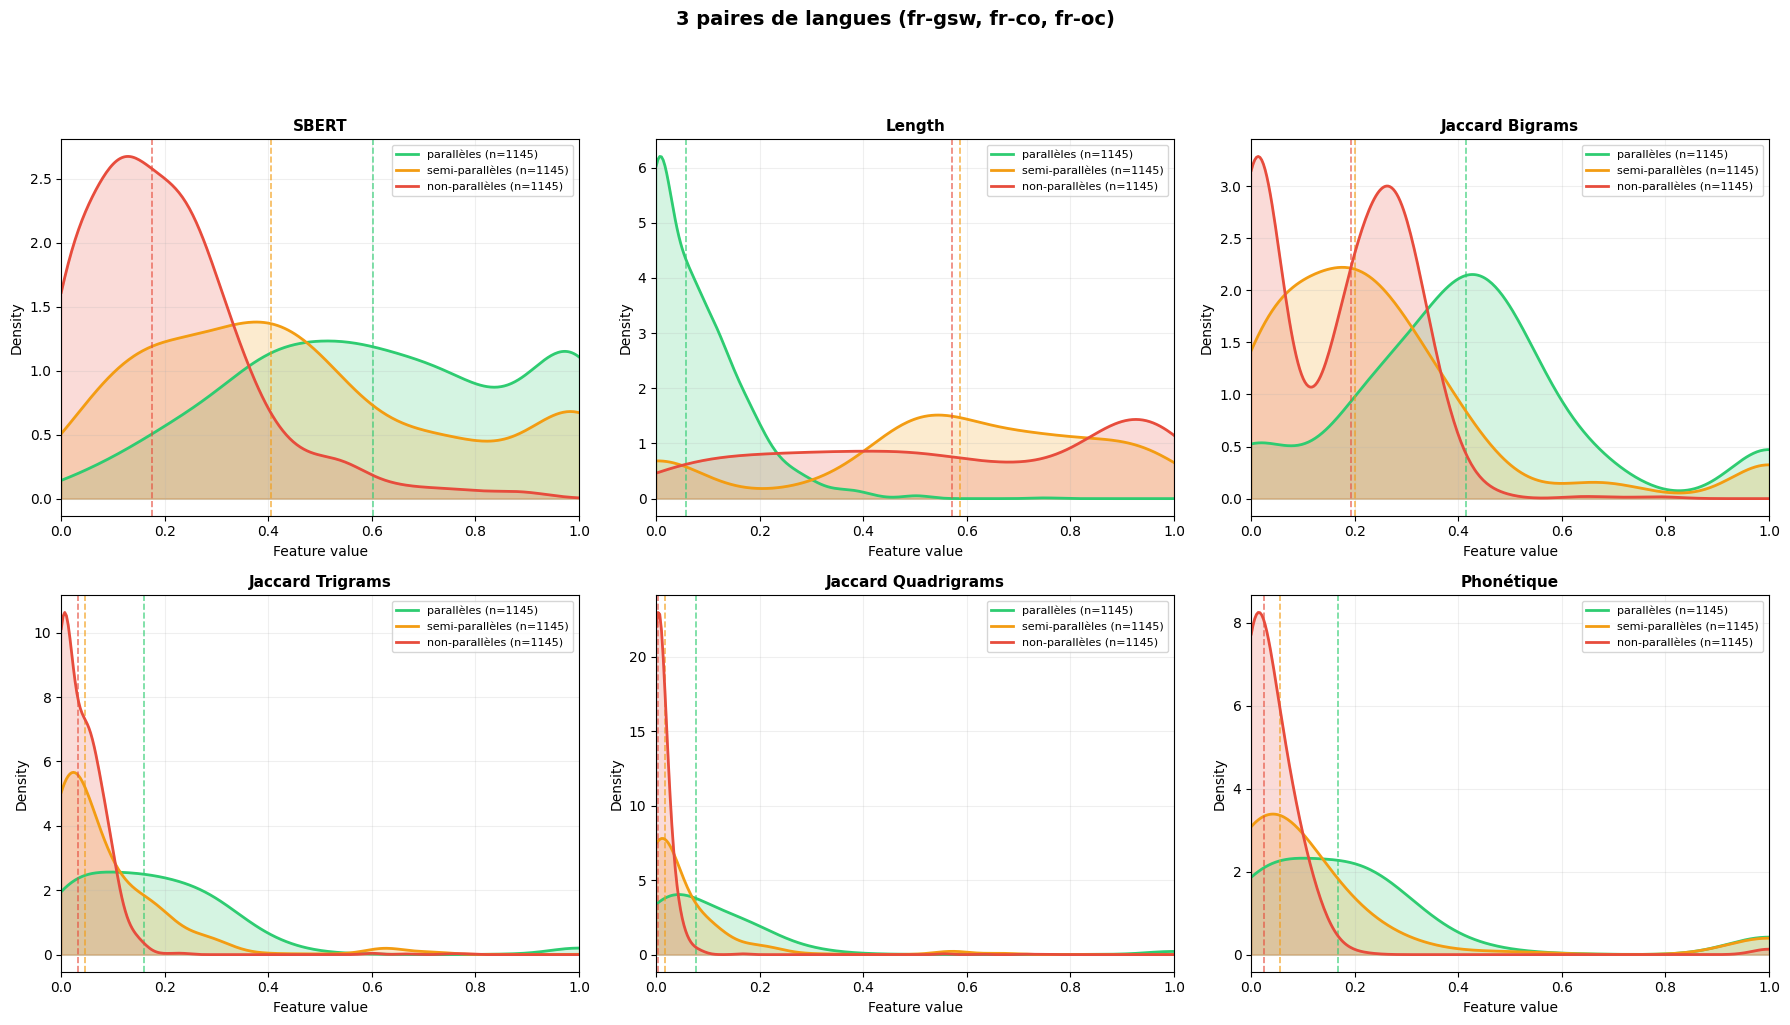

Graphique sauvegardé : fig_kde_all_3_languages.png

[paires romanes (fr-co, fr-oc)] 2611 samples


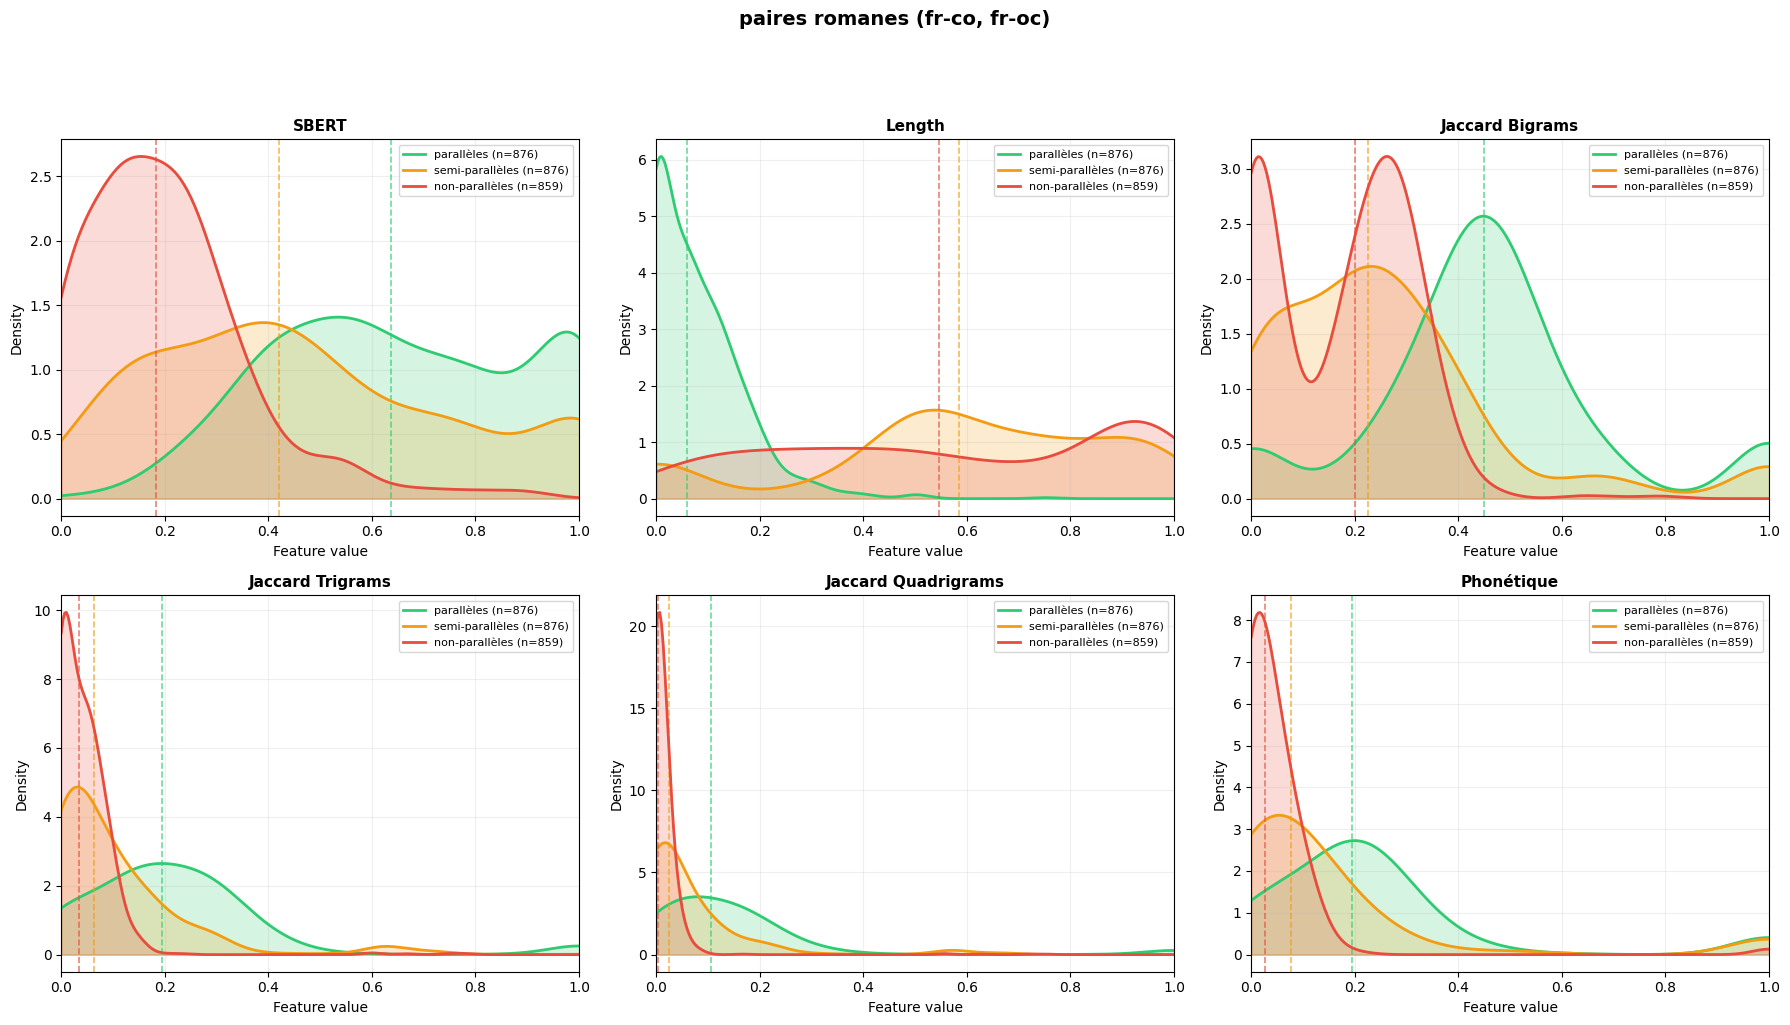

Graphique sauvegardé : fig_kde_romance_classes.png

[paires alsaciennes (fr-gsw)] 824 samples


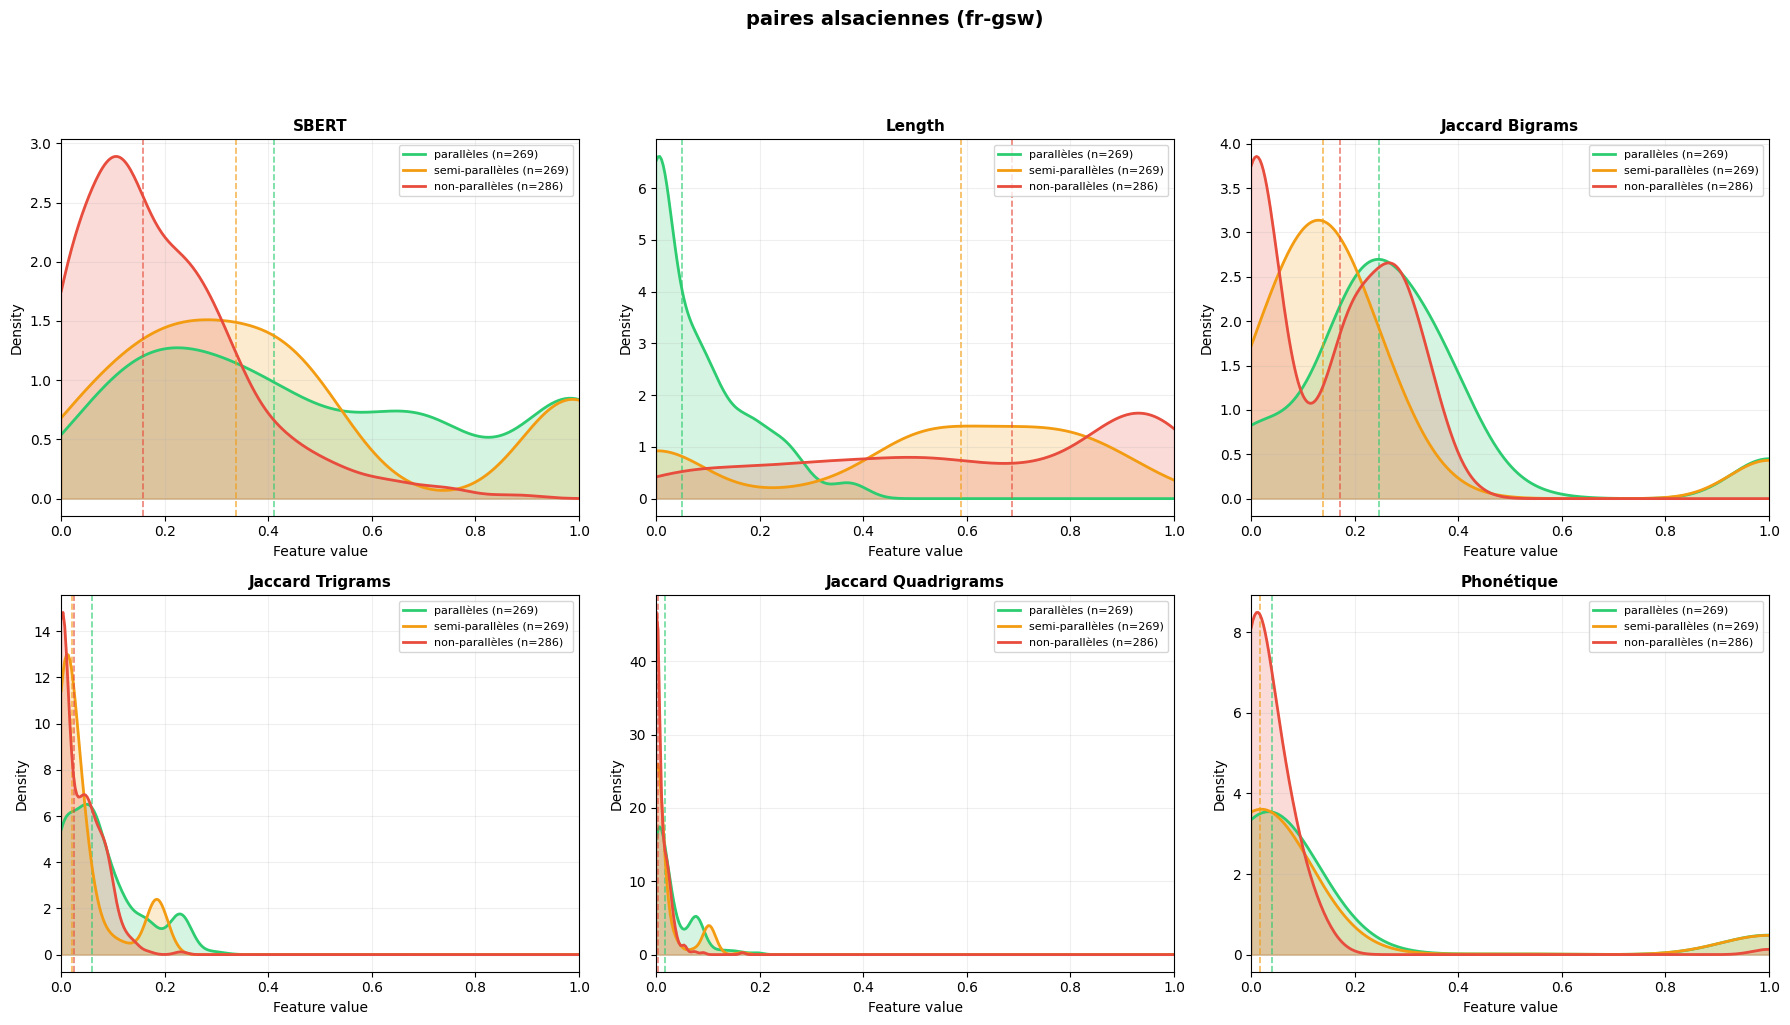

Graphique sauvegardé : fig_kde_gsw_classes.png

Tous les graphiques KDE par classe ont été générés.

Résumé des statistiques par feature et par classe

3 paires de langues (fr-gsw, fr-co, fr-oc) (n=3435):
  SBERT          :
    parallèles      (n= 1145) | médiane=0.6017  moy=0.6165  σ=0.2725
    semi-parallèles (n= 1145) | médiane=0.4052  moy=0.4594  σ=0.2979
    non-parallèles  (n= 1145) | médiane=0.1760  moy=0.2004  σ=0.1601
  Length         :
    parallèles      (n= 1145) | médiane=0.0571  moy=0.0790  σ=0.0896
    semi-parallèles (n= 1145) | médiane=0.5862  moy=0.5617  σ=0.2962
    non-parallèles  (n= 1145) | médiane=0.5714  moy=0.5750  σ=0.3258
  Jaccard Bigrams:
    parallèles      (n= 1145) | médiane=0.4149  moy=0.4211  σ=0.2447
    semi-parallèles (n= 1145) | médiane=0.2000  moy=0.2499  σ=0.2408
    non-parallèles  (n= 1145) | médiane=0.1935  moy=0.1676  σ=0.1343
  Jaccard Trigrams:
    parallèles      (n= 1145) | médiane=0.1597  moy=0.1868  σ=0.1848
    semi-parallèles (n= 1145

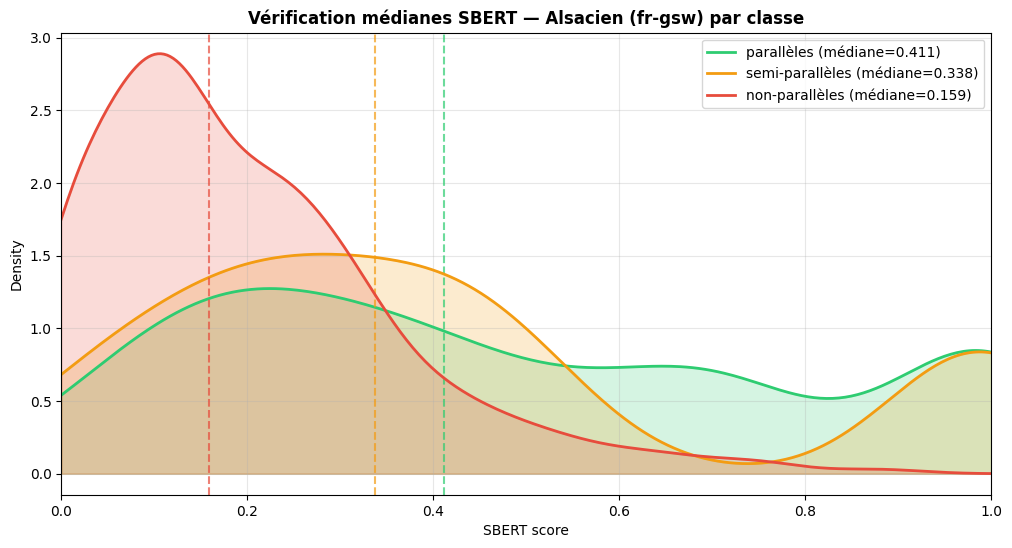


Graphique de vérification sauvegardé : fig_median_verification_gsw.png


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Configuration des features
FEATURES = [
    "sbert_score", "length_score",
    "jaccard_bigrams", "jaccard_trigrams", "jaccard_quadrigrams", "phonetic_jaccard"
]

FEATURE_NAMES = {
    "sbert_score": "SBERT",
    "length_score": "Length",
    "jaccard_bigrams": "Jaccard Bigrams",
    "jaccard_trigrams": "Jaccard Trigrams",
    "jaccard_quadrigrams": "Jaccard Quadrigrams",
    "phonetic_jaccard": "Phonétique"
}

# Palette de couleurs par classe
CLASS_COLORS = {
    "non-parallel": "#e74c3c",
    "semi-parallel": "#f39c12",
    "parallel": "#2ecc71",
}

CLASS_NAMES = {
    "parallel": "parallèles",
    "semi-parallel": "semi-parallèles",
    "non-parallel": "non-parallèles",
}

# Définition des 3 groupes de paires de langues
GROUPS = {
    "3 paires de langues (fr-gsw, fr-co, fr-oc)": ["fr-gsw", "fr-co", "fr-oc"],
    "paires romanes (fr-co, fr-oc)": ["fr-co", "fr-oc"],
    "paires alsaciennes (fr-gsw)": ["fr-gsw"],
}

def plot_kde_grid_by_class(data, group_title, fname):
    """Grille 2 lignes x 3 colonnes : chaque case = 1 feature, 3 courbes KDE (une par classe)."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for i, feature in enumerate(FEATURES):
        col = i % 3
        row = i // 3
        ax = axes[row, col]

        for cls_label in ["parallel", "semi-parallel", "non-parallel"]:
            data_cls = data[data["class"] == cls_label][feature].dropna()
            if len(data_cls) < 2:
                continue

            kde = gaussian_kde(data_cls, bw_method=0.3)
            x_range = np.linspace(0, 1, 300)
            y_kde = kde(x_range)

            color = CLASS_COLORS[cls_label]
            median_val = data_cls.median()

            ax.fill_between(x_range, y_kde, alpha=0.2, color=color)
            ax.plot(x_range, y_kde, color=color, linewidth=2,
                    label=f"{CLASS_NAMES[cls_label]} (n={len(data_cls)})")
            ax.axvline(median_val, color=color, linestyle="--", linewidth=1.2, alpha=0.7)

        ax.set_title(FEATURE_NAMES[feature], fontsize=11, fontweight="bold")
        ax.set_xlim(0, 1)
        ax.set_xlabel("Feature value")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True, alpha=0.2)

    fig.suptitle(group_title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Graphique sauvegardé : {fname}")

# Génération des 3 graphiques KDE par classe (grille 2x3)
print("Génération des graphiques KDE par feature et par classe (grille 2x3)...")
print("=" * 60)

for group_name, lp_list in GROUPS.items():
    lp_filter = [f"fr-{lp.split("-")[1]}" for lp in lp_list]
    group_data = df[df["language_pair"].isin(lp_filter)].copy()

    if group_name == "3 paires de langues (fr-gsw, fr-co, fr-oc)":
        fname = "fig_kde_all_3_languages.png"
    elif group_name == "paires romanes (fr-co, fr-oc)":
        fname = "fig_kde_romance_classes.png"
    else:
        fname = "fig_kde_gsw_classes.png"

    print(f"\n[{group_name}] {len(group_data)} samples")
    plot_kde_grid_by_class(group_data, group_name, fname)

print("\n" + "=" * 60)
print("Tous les graphiques KDE par classe ont été générés.")

# Résumé détaillé par feature x classe
print("\n" + "=" * 60)
print("Résumé des statistiques par feature et par classe")
print("=" * 60)
for group_name, lp_list in GROUPS.items():
    lp_filter = [f"fr-{lp.split("-")[1]}" for lp in lp_list]
    group_data = df[df["language_pair"].isin(lp_filter)]
    print(f"\n{group_name} (n={len(group_data)}):")
    for feat in FEATURES:
        print(f"  {FEATURE_NAMES[feat]:15s}:")
        for cls in ["parallel", "semi-parallel", "non-parallel"]:
            vals = group_data[group_data["class"] == cls][feat].dropna()
            if len(vals) > 0:
                print(f"    {CLASS_NAMES[cls]:15s} (n={len(vals):5d}) | médiane={vals.median():.4f}  moy={vals.mean():.4f}  σ={vals.std():.4f}")

# Vérification des médianes SBERT par classe
print("\n" + "=" * 60)
print("Vérification des médianes SBERT par classe — Alsacien (fr-gsw)")
print("=" * 60)

gsw_df = df[df["language_pair"] == "fr-gsw"]

# Médianes par classe (issue du KDE)
print("\nMédianes SBERT par classe (alsacien, issue du KDE) :")
median_by_class_gsw = gsw_df.groupby("class")["sbert_score"].median()
for cls, med in median_by_class_gsw.items():
    print(f"  {CLASS_NAMES[cls]:15s} : {med:.4f}")

# Comparaison globale
median_gsw_global = gsw_df["sbert_score"].median()
median_by_pair = df.groupby("language_pair")["sbert_score"].median()
median_gsw_pair = median_by_pair.get("fr-gsw", float("nan"))
diff_global = abs(median_gsw_global - median_gsw_pair)
print(f"\nMédiane globale KDE (alsacien):     {median_gsw_global:.4f}")
print(f"Médiane globale par paire (fr-gsw): {median_gsw_pair:.4f}")
print(f"Différence globale: {diff_global:.6f}")
if diff_global < 1e-10:
    print("VÉRIFICATION PASSÉE (globale): Les deux médianes sont identiques.")
else:
    print("ATTENTION: Les médianes globales diffèrent.")

# Vérification par classe
print("\nVérification par classe (les données sont les mêmes, les médianes doivent coïncider) :")
all_ok = True
for cls in ["parallel", "semi-parallel", "non-parallel"]:
    vals = gsw_df[gsw_df["class"] == cls]["sbert_score"].dropna()
    med_kde = vals.median()
    med_groupby = gsw_df[gsw_df["class"] == cls].groupby("class")["sbert_score"].median()[cls]
    diff_cls = abs(med_kde - med_groupby)
    status = "OK" if diff_cls < 1e-10 else "DIFFÉRENT"
    if diff_cls >= 1e-10:
        all_ok = False
    print(f"  {CLASS_NAMES[cls]:15s} : médiane={med_kde:.4f} (diff={diff_cls:.8f}) [{status}]")

if all_ok:
    print("\nVÉRIFICATION PASSÉE (par classe): Toutes les médianes sont identiques.")
else:
    print("\nATTENTION: Certaines médianes par classe diffèrent.")

# Graphique de vérification : KDE SBERT par classe pour l’alsacien
fig2, ax2 = plt.subplots(figsize=(12, 6))
for cls_label in ["parallel", "semi-parallel", "non-parallel"]:
    data_cls = gsw_df[gsw_df["class"] == cls_label]["sbert_score"].dropna()
    if len(data_cls) < 2:
        continue
    kde = gaussian_kde(data_cls, bw_method=0.3)
    x_range = np.linspace(0, 1, 300)
    y_kde = kde(x_range)
    color = CLASS_COLORS[cls_label]
    median_val = data_cls.median()
    ax2.fill_between(x_range, y_kde, alpha=0.2, color=color)
    ax2.plot(x_range, y_kde, color=color, linewidth=2,
             label=f"{CLASS_NAMES[cls_label]} (médiane={median_val:.3f})")
    ax2.axvline(median_val, color=color, linestyle="--", linewidth=1.5, alpha=0.7)

ax2.set_title("Vérification médianes SBERT — Alsacien (fr-gsw) par classe",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("SBERT score")
ax2.set_ylabel("Density")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)
fig2.savefig("fig_median_verification_gsw.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGraphique de vérification sauvegardé : fig_median_verification_gsw.png")
